<a href="https://colab.research.google.com/github/Alister44/DTA_2026_DE/blob/main/Hausafgaben/HW_5_pandas_matplotlib_80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 Pandas + Matplotlib: Praktikum mit 80 Aufgaben

**Niveau:** mittel (pandas) + Anfänger (matplotlib)

---

Dieses Notebook enthält **80 Aufgaben**:
- **50 pandas-Aufgaben** — wir vertiefen das Gelernte, fügen `loc`/`iloc`, `pivot_table`, komplexeres `groupby` hinzu
- **30 Visualisierungsaufgaben** — pandas `.plot()` + matplotlib-Grundlagen mit Farben, Stilen und Legenden

## Daten
Wir arbeiten mit den Daten eines Streaming-Dienstes. Zwei Dateien:

**`streaming_subscribers.csv`** (600 Zeilen) — Abonnenten des Dienstes:

| Spalte | Beschreibung |
|---|---|
| `subscriber_id` | Eindeutige Abonnenten-Nummer |
| `age` | Alter |
| `gender` | Geschlecht (m / f) |
| `country` | Land (Ukraine, Poland, Germany, Czech Republic, Lithuania, Spain) |
| `plan` | Tarif (Basic / Standard / Premium / Family) |
| `monthly_fee` | Monatliche Gebühr (€) |
| `join_date` | Registrierungsdatum |
| `is_active` | Aktives Abo (Yes / No) |

**`streaming_sessions.csv`** (5000 Zeilen) — Streaming-Sitzungen:

| Spalte | Beschreibung |
|---|---|
| `session_id` | Eindeutige Sitzungsnummer |
| `subscriber_id` | ID des Abonnenten (Verknüpfung mit der ersten Tabelle) |
| `date` | Datum der Wiedergabe |
| `genre` | Genre |
| `device` | Gerät (Smart TV / Laptop / Mobile / Tablet) |
| `duration_min` | Wiedergabedauer in Minuten |
| `rating` | Bewertung des Nutzers (1-5) |

## So arbeitest du
- In jeder Zelle gibt es einen Kommentar mit der Aufgabennummer — schreibe deinen Code darunter
- Führe jede Zelle aus (Shift + Enter), um das Ergebnis zu sehen
- Wenn du die Syntax vergessen hast — nutze den pandas-Spickzettel und den neuen matplotlib-Spickzettel
- Hab keine Angst zu experimentieren!

---


## Vorbereitung

Führe diese Zelle aus — sie lädt die Bibliotheken und Daten. Alle Aufgaben verwenden die Variablen `subs` (Abonnenten) und `sess` (Sitzungen).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

subs = pd.read_csv("https://raw.githubusercontent.com/Alister44/DTA_2026_DE/refs/heads/main/data/streaming_subscribers.csv")
sess = pd.read_csv("https://raw.githubusercontent.com/Alister44/DTA_2026_DE/refs/heads/main/data/streaming_sessions.csv")

# Wandeln die Daten in ein echtes Format um
subs["join_date"] = pd.to_datetime(subs["join_date"])
sess["date"] = pd.to_datetime(sess["date"])

print("Abonnenten:", subs.shape)
print("Sitzungen:", sess.shape)
subs.head()


Abonnenten: (600, 8)
Sitzungen: (5000, 7)


,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active
0,1001,19,m,Ukraine,Premium,329,2023-02-27,No
1,1002,40,f,Poland,Standard,219,2022-03-05,Yes
2,1003,60,m,Ukraine,Basic,149,2023-02-20,Yes
3,1004,36,m,Czech Republic,Basic,149,2022-02-22,Yes
4,1005,34,f,Spain,Standard,219,2023-08-27,Yes


In [2]:
sess.head()

,session_id,subscriber_id,date,genre,device,duration_min,rating
0,51573,1166,2024-04-11,Animation,Mobile,72,1
1,50017,1429,2024-06-25,Romance,Mobile,53,5
2,50861,1404,2024-07-05,Action,Smart TV,49,5
3,54446,1520,2024-07-01,Series,Laptop,66,3
4,51561,1052,2024-06-13,Action,Laptop,81,5


---

# Teil 1. Pandas (50 Aufgaben)

Kapitel:
1. Aufwärmen — Wiederholung (1-8)
2. `loc` und `iloc` — Auswahl nach Position und Bezeichnung (9-18)
3. Komplexeres groupby (19-28)
4. `pivot_table` — Pivot-Tabellen (29-36)
5. Arbeiten mit Datumsangaben + Berechnungen (37-44)
6. Kombinierte Aufgaben (45-50)


## Kapitel 1.1. Aufwärmen (Aufgaben 1-8)

Schnelle Wiederholung dessen, was wir schon wissen.


**Aufgabe 1.** Gib die ersten 10 Zeilen der Tabelle `sess` aus.


In [3]:
# Aufgabe 1:
sess.head(10)


,session_id,subscriber_id,date,genre,device,duration_min,rating
0,51573,1166,2024-04-11,Animation,Mobile,72,1
1,50017,1429,2024-06-25,Romance,Mobile,53,5
2,50861,1404,2024-07-05,Action,Smart TV,49,5
3,54446,1520,2024-07-01,Series,Laptop,66,3
4,51561,1052,2024-06-13,Action,Laptop,81,5
5,51938,1078,2024-08-27,Documentary,Mobile,60,4
6,52050,1343,2024-02-26,Action,Tablet,86,3
7,54963,1444,2024-08-04,Series,Smart TV,56,4
8,50908,1521,2024-04-02,Drama,Smart TV,68,4
9,51976,1555,2024-04-11,Drama,Mobile,84,5


**Aufgabe 2.** Wie viele Abonnenten gibt es insgesamt in den Daten? Und Sitzungen?

> 💡 Attribut `shape[0]` oder die Funktion `len()`.


In [4]:
# Aufgabe 2:
print(subs.shape[0])
print(len(subs))


600
600


**Aufgabe 3.** Gib die Anzahl der Abonnenten für jedes Land aus. Sortiere absteigend.

> 💡 `value_counts()` sortiert bereits standardmäßig absteigend.


In [5]:
# Aufgabe 3:
subs['country'].value_counts()


,count
country,
Ukraine,256
Germany,101
Poland,77
Czech Republic,68
Spain,62
Lithuania,36


**Aufgabe 4.** Finde das Durchschnittsalter der Abonnenten.


In [6]:
# Aufgabe 4:
subs.age.mean()


np.float64(43.163333333333334)

**Aufgabe 5.** Finde die minimale und maximale Sitzungsdauer.


In [7]:
# Aufgabe 5:
print("minimale Sitzungsdauer- ", sess.duration_min.min())
print("maximale Sitzungsdauer- ", sess.duration_min.max())


minimale Sitzungsdauer-  5
maximale Sitzungsdauer-  171


**Aufgabe 6.** Wie viele Abonnenten sind aktiv (`is_active == "Yes"`)?


In [8]:
# Aufgabe 6:
(subs['is_active'] == 'Yes').sum()


np.int64(447)

**Aufgabe 7.** Gib nur die Sitzungen des Genres `Drama` mit einer Bewertung von 5 aus.

> 💡 Zwei Bedingungen mit `&`, jede in Klammern.


In [9]:
# Aufgabe 7:
sess[(sess['genre'] == "Drama") & (sess['rating'] == 5)]


,session_id,subscriber_id,date,genre,device,duration_min,rating
9,51976,1555,2024-04-11,Drama,Mobile,84,5
68,51372,1447,2024-06-19,Drama,Tablet,93,5
74,53138,1074,2024-01-05,Drama,Laptop,48,5
94,52201,1124,2024-06-17,Drama,Laptop,34,5
117,53459,1454,2024-05-04,Drama,Mobile,77,5
...,...,...,...,...,...,...,...
4852,52566,1345,2024-03-28,Drama,Laptop,43,5
4855,51811,1579,2024-04-04,Drama,Smart TV,99,5
4902,53655,1551,2024-06-30,Drama,Laptop,48,5
4939,50494,1468,2024-01-30,Drama,Smart TV,36,5


**Aufgabe 8.** Erstelle in der Tabelle `subs` eine neue Spalte `annual_fee` = `monthly_fee` × 12.


In [10]:
# Aufgabe 8:
subs['annual_fee'] = subs['monthly_fee'] * 12
subs.head()


,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
0,1001,19,m,Ukraine,Premium,329,2023-02-27,No,3948
1,1002,40,f,Poland,Standard,219,2022-03-05,Yes,2628
2,1003,60,m,Ukraine,Basic,149,2023-02-20,Yes,1788
3,1004,36,m,Czech Republic,Basic,149,2022-02-22,Yes,1788
4,1005,34,f,Spain,Standard,219,2023-08-27,Yes,2628


## Kapitel 1.2. loc und iloc (Aufgaben 9-18)

`iloc` arbeitet nach **numerischen Positionen** (wie Indizes in einer Liste):
- `df.iloc[0]` — erste Zeile
- `df.iloc[0:5]` — Zeilen 0-4
- `df.iloc[0, 2]` — Zeile 0, Spalte 2
- `df.iloc[:, 1:3]` — alle Zeilen, Spalten 1-2

`loc` arbeitet nach **Bezeichnungen** (Namen):
- `df.loc[0]` — Zeile mit Bezeichnung 0
- `df.loc[df["age"] > 30, "country"]` — Filter + bestimmte Spalte
- `df.loc[df["plan"] == "Premium", ["age", "country"]]` — Filter + mehrere Spalten


**Aufgabe 9.** Gib die erste Zeile der Tabelle `subs` mit `iloc` aus.

> 💡 `subs.iloc[0]`.


In [11]:
# Aufgabe 9:
subs.iloc[0]


,0
subscriber_id,1001
age,19
gender,m
country,Ukraine
plan,Premium
monthly_fee,329
join_date,2023-02-27 00:00:00
is_active,No
annual_fee,3948


**Aufgabe 10.** Gib die Zeilen 10 bis einschließlich 15 der Tabelle `subs` mit `iloc` aus.

> 💡 `iloc[10:16]` (das rechte Ende ist nicht eingeschlossen).


In [12]:
# Aufgabe 10:
subs.iloc[10:16]


,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
10,1011,16,m,Spain,Family,449,2023-09-17,Yes,5388
11,1012,56,m,Ukraine,Standard,219,2024-12-08,Yes,2628
12,1013,25,m,Spain,Standard,219,2023-01-01,Yes,2628
13,1014,17,m,Ukraine,Standard,219,2023-07-21,Yes,2628
14,1015,55,f,Ukraine,Standard,219,2022-02-14,No,2628
15,1016,20,m,Poland,Premium,329,2022-06-09,No,3948


**Aufgabe 11.** Gib den Wert aus der 5. Zeile, 3. Spalte der Tabelle `subs` aus.

> 💡 `iloc[5, 3]`. Nullbasierte Nummerierung!


In [13]:
# Aufgabe 11:
subs.iloc[4,2]


'f'

**Aufgabe 12.** Gib die ersten 3 Spalten der Tabelle `sess` aus (alle Zeilen) mit `iloc`.

> 💡 `iloc[:, :3]`.


In [14]:
# Aufgabe 12:
sess.iloc[:,:3]


,session_id,subscriber_id,date
0,51573,1166,2024-04-11
1,50017,1429,2024-06-25
2,50861,1404,2024-07-05
3,54446,1520,2024-07-01
4,51561,1052,2024-06-13
...,...,...,...
4995,52398,1356,2024-08-19
4996,51013,1208,2024-03-17
4997,54579,1174,2024-05-25
4998,52743,1431,2024-07-23


**Aufgabe 13.** Gib die Zeilen 100-104 aus, nur die Spalten `age` und `country`. Verwende `iloc`.

> 💡 `iloc[100:105, [1, 3]]` — Spaltenindizes: age=1, country=3.


In [15]:
# Aufgabe 13:
subs.iloc[99:104,[1,3]]


,age,country
99,41,Czech Republic
100,63,Poland
101,21,Germany
102,62,Poland
103,48,Ukraine


**Aufgabe 14.** Gib mit `loc` nur die Abonnenten aus, deren Alter über 50 ist. Gib nur die Spalten `country` und `plan` zurück.

> 💡 `subs.loc[subs["age"] > 50, ["country", "plan"]]`.


In [16]:
# Aufgabe 14:
subs.loc[subs['age'] >  50,['country', 'plan']] # work better(1 operation)


,country,plan
2,Ukraine,Basic
11,Ukraine,Standard
14,Ukraine,Standard
16,Germany,Standard
18,Poland,Standard
...,...,...
593,Spain,Basic
594,Ukraine,Basic
595,Ukraine,Premium
598,Czech Republic,Standard


In [17]:
subs[subs['age'] >  50][['country','plan']] # work slowlier


,country,plan
2,Ukraine,Basic
11,Ukraine,Standard
14,Ukraine,Standard
16,Germany,Standard
18,Poland,Standard
...,...,...
593,Spain,Basic
594,Ukraine,Basic
595,Ukraine,Premium
598,Czech Republic,Standard


**Aufgabe 15.** Gib mit `loc` die Spalte `monthly_fee` nur für aktive Abonnenten aus (`is_active == "Yes"`).


In [18]:
# Aufgabe 15:
subs.loc[subs['is_active'] == 'Yes', 'monthly_fee']


,monthly_fee
1,219
2,149
3,149
4,219
5,219
...,...
594,149
595,329
596,449
597,449


**Aufgabe 16.** Finde das Durchschnittsalter der Abonnenten mit dem Tarif `Premium` mit `loc`.

> 💡 `subs.loc[subs["plan"]=="Premium", "age"].mean()`.


In [19]:
# Aufgabe 16:
subs.loc[subs['plan'] == "Premium",'age'].mean().round()


np.float64(42.0)

**Aufgabe 17.** Ändere mit `loc` den Wert von `is_active` auf `"Yes"` für den Abonnenten mit `subscriber_id == 1001`.

> 💡 `subs.loc[subs["subscriber_id"]==1001, "is_active"] = "Yes"`. Überprüfe danach das Ergebnis.


In [20]:
# Aufgabe 17:
subs.loc[subs['subscriber_id'] == 1001, "is_active"] = 'Yes'
subs[subs['subscriber_id'] == 1001]


,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
0,1001,19,m,Ukraine,Premium,329,2023-02-27,Yes,3948


**Aufgabe 18.** Gib die letzten 5 Zeilen der Tabelle `subs` mit `iloc` aus (ohne `tail`).

> 💡 Negative Indizes: `iloc[-5:]`.


In [21]:
# Aufgabe 18:
subs.iloc[-5:]


,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
595,1596,53,f,Ukraine,Premium,329,2022-04-15,Yes,3948
596,1597,30,m,Ukraine,Family,449,2024-03-26,Yes,5388
597,1598,38,m,Germany,Family,449,2024-06-12,Yes,5388
598,1599,64,f,Czech Republic,Standard,219,2024-05-03,No,2628
599,1600,68,m,Poland,Standard,219,2022-07-28,Yes,2628


## Kapitel 1.3. Komplexeres groupby (Aufgaben 19-28)

Neue Möglichkeiten:
- `.agg(["sum", "mean", "count"])` — mehrere Aggregate auf einmal
- `.agg({"col1": "mean", "col2": "sum"})` — verschiedene Aggregate für verschiedene Spalten
- `.transform("mean")` — gibt für jede Zeile der Gruppe dieselbe Zahl zurück (praktisch für neue Spalten)
- `groupby(["col1", "col2"])` — Gruppierung nach mehreren Spalten
- `.size()` — Anzahl der Zeilen in jeder Gruppe


**Aufgabe 19.** Gib für jedes Land die Anzahl der Abonnenten und das Durchschnittsalter mit einem `agg`-Aufruf aus.

> 💡 `subs.groupby("country").agg({"subscriber_id": "count", "age": "mean"})`.


In [22]:
# Aufgabe 19:
subs.groupby("country").agg({
    'subscriber_id': 'count',
    'age': 'mean'
}).round(0)


,subscriber_id,age
country,,
Czech Republic,68,41.0
Germany,101,45.0
Lithuania,36,40.0
Poland,77,43.0
Spain,62,43.0
Ukraine,256,44.0


**Aufgabe 20.** Gib für jeden Tarif (`plan`) das minimale, durchschnittliche und maximale Alter der Abonnenten aus.

> 💡 `agg(["min", "mean", "max"])` auf der Spalte `age`.


In [23]:
# Aufgabe 20:
subs.groupby('plan')['age'].agg(['min','max','mean']).round()


,min,max,mean
plan,,,
Basic,16,70,45.0
Family,16,70,42.0
Premium,16,70,42.0
Standard,16,70,43.0


**Aufgabe 21.** Berechne für jedes Genre in der Tabelle `sess` die Anzahl der Sitzungen und die durchschnittliche Dauer.

> 💡 `sess.groupby("genre").agg({"session_id": "count", "duration_min": "mean"})`.


In [24]:
# Aufgabe 21:
sess.groupby("genre").agg({
    "session_id": "count",
    "duration_min": "mean"
}).round(2)


,session_id,duration_min
genre,,
Action,661,52.86
Animation,653,53.43
Comedy,629,54.13
Documentary,573,52.66
Drama,578,52.86
Horror,631,52.24
Romance,644,54.71
Series,631,53.95


**Aufgabe 22.** Berechne für jedes Gerät die durchschnittliche Bewertung (`rating`) und die durchschnittliche Dauer (`duration_min`).


In [25]:
# Aufgabe 22:
sess.groupby("device").agg({
    "rating": "mean",
    "duration_min": "mean"
})


,rating,duration_min
device,,
Laptop,3.983550,52.854010
Mobile,3.991426,52.825409
Smart TV,4.052541,53.613935
Tablet,4.007890,55.376726


**Aufgabe 23.** Gruppiere die Sitzungen nach zwei Spalten: `genre` und `device`. Berechne die durchschnittliche Bewertung.

> 💡 `groupby(["genre", "device"])["rating"].mean()`.


In [26]:
# Aufgabe 23:
sess.groupby(["genre","device"])["rating"].mean().round(2)


genre        device  
Action       Laptop      4.08
             Mobile      3.81
             Smart TV    3.91
             Tablet      4.07
Animation    Laptop      3.91
             Mobile      4.07
             Smart TV    4.01
             Tablet      3.88
Comedy       Laptop      3.99
             Mobile      4.02
             Smart TV    4.02
             Tablet      3.97
Documentary  Laptop      4.03
             Mobile      4.00
             Smart TV    4.12
             Tablet      3.98
Drama        Laptop      3.97
             Mobile      4.11
             Smart TV    4.11
             Tablet      4.20
Horror       Laptop      3.96
             Mobile      3.99
             Smart TV    4.08
             Tablet      4.14
Romance      Laptop      4.00
             Mobile      3.92
             Smart TV    4.09
             Tablet      4.09
Series       Laptop      3.94
             Mobile      4.05
             Smart TV    4.10
             Tablet      3.72
Name: rating, dtype: float64

**Aufgabe 24.** Wie viele Sitzungen entfallen auf jedes Paar (`genre`, `device`)? Verwende `.size()`.


In [27]:
# Aufgabe 24:
sess.groupby(["genre","device"]).size()


genre        device  
Action       Laptop      193
             Mobile      175
             Smart TV    223
             Tablet       70
Animation    Laptop      185
             Mobile      166
             Smart TV    227
             Tablet       75
Comedy       Laptop      184
             Mobile      154
             Smart TV    233
             Tablet       58
Documentary  Laptop      175
             Mobile      136
             Smart TV    214
             Tablet       48
Drama        Laptop      154
             Mobile      158
             Smart TV    207
             Tablet       59
Horror       Laptop      180
             Mobile      162
             Smart TV    210
             Tablet       79
Romance      Laptop      203
             Mobile      166
             Smart TV    217
             Tablet       58
Series       Laptop      185
             Mobile      166
             Smart TV    220
             Tablet       60
dtype: int64

**Aufgabe 25.** Füge der Tabelle `sess` eine neue Spalte `avg_rating_genre` hinzu — die durchschnittliche Bewertung nach Genre für diese Sitzung. Verwende `.transform("mean")`.

> 💡 `sess["avg_rating_genre"] = sess.groupby("genre")["rating"].transform("mean")`.


In [28]:
# Aufgabe 25:
sess["avg_rating_genre"] = sess.groupby('genre')['rating'].transform('mean').round(2)
sess.head(10)


,session_id,subscriber_id,date,genre,device,duration_min,rating,avg_rating_genre
0,51573,1166,2024-04-11,Animation,Mobile,72,1,3.98
1,50017,1429,2024-06-25,Romance,Mobile,53,5,4.02
2,50861,1404,2024-07-05,Action,Smart TV,49,5,3.95
3,54446,1520,2024-07-01,Series,Laptop,66,3,4.00
4,51561,1052,2024-06-13,Action,Laptop,81,5,3.95
5,51938,1078,2024-08-27,Documentary,Mobile,60,4,4.05
6,52050,1343,2024-02-26,Action,Tablet,86,3,3.95
7,54963,1444,2024-08-04,Series,Smart TV,56,4,4.00
8,50908,1521,2024-04-02,Drama,Smart TV,68,4,4.08
9,51976,1555,2024-04-11,Drama,Mobile,84,5,4.08


**Aufgabe 26.** Füge der Tabelle `subs` die Spalte `avg_age_country` hinzu — das Durchschnittsalter der Abonnenten im Land dieses Abonnenten.


In [29]:
# Aufgabe 26:
subs['avg_age_country'] = subs.groupby('country')['age'].transform('mean').round()
subs.head(10)


,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee,avg_age_country
0,1001,19,m,Ukraine,Premium,329,2023-02-27,Yes,3948,44.0
1,1002,40,f,Poland,Standard,219,2022-03-05,Yes,2628,43.0
2,1003,60,m,Ukraine,Basic,149,2023-02-20,Yes,1788,44.0
3,1004,36,m,Czech Republic,Basic,149,2022-02-22,Yes,1788,41.0
4,1005,34,f,Spain,Standard,219,2023-08-27,Yes,2628,43.0
5,1006,37,f,Poland,Standard,219,2024-11-17,Yes,2628,43.0
6,1007,16,f,Ukraine,Premium,329,2024-07-22,Yes,3948,44.0
7,1008,49,m,Germany,Standard,219,2022-11-06,Yes,2628,45.0
8,1009,47,f,Germany,Basic,149,2023-09-13,No,1788,45.0
9,1010,40,f,Germany,Standard,219,2022-10-03,No,2628,45.0


**Aufgabe 27.** Finde das Land mit dem höchsten Durchschnittsalter der Abonnenten.

> 💡 `groupby + mean + idxmax()` ODER `sort_values(ascending=False).head(1)`.


In [30]:
subs.groupby("country")["age"].mean().idxmax()
subs.groupby("country")["age"].mean().sort_values(ascending=False).round().head(1)



,age
country,
Germany,45.0


**Aufgabe 28.** Berechne für jedes Land, wie viele aktive und wie viele inaktive Abonnenten es gibt. Verwende `groupby` nach zwei Spalten + `size()`.

> 💡 `subs.groupby(["country", "is_active"]).size()`.


In [31]:
# Aufgabe 28:
subs.groupby(["country","is_active"]).size()


country         is_active
Czech Republic  No            13
                Yes           55
Germany         No            29
                Yes           72
Lithuania       No             7
                Yes           29
Poland          No            21
                Yes           56
Spain           No            16
                Yes           46
Ukraine         No            66
                Yes          190
dtype: int64

## Kapitel 1.4. pivot_table — Pivot-Tabellen (Aufgaben 29-36)

`pivot_table` erstellt eine Tabelle, bei der:
- `index` — was wir in die Zeilen setzen
- `columns` — was wir in die Spalten setzen
- `values` — was wir berechnen
- `aggfunc` — welches Aggregat (standardmäßig `"mean"`)

Beispiel:
```python
pd.pivot_table(df, index="country", columns="plan", values="age", aggfunc="mean")
```


**Aufgabe 29.** Erstelle eine Pivot-Tabelle: Zeilen — `country`, Spalten — `plan`, Werte — Anzahl der Abonnenten.

> 💡 `aggfunc="count"`, als `values` kann `subscriber_id` genommen werden.


In [32]:
# Aufgabe 29:
pd.pivot_table(subs,
               index="country",
               columns="plan",
               values="subscriber_id",
               aggfunc="count")


plan,Basic,Family,Premium,Standard
country,,,,
Czech Republic,13,16,16,23
Germany,24,17,19,41
Lithuania,5,7,10,14
Poland,10,9,23,35
Spain,18,9,13,22
Ukraine,68,34,60,94


**Aufgabe 30.** Pivot-Tabelle: Zeilen — `country`, Spalten — `plan`, Werte — Durchschnittsalter.

> 💡 `aggfunc="mean"` (Standard).


In [33]:
# Aufgabe 30:
pd.pivot_table(
    subs,
    index='country',
    columns='plan',
    values='age',
    aggfunc='mean'
).round(0)


plan,Basic,Family,Premium,Standard
country,,,,
Czech Republic,41.0,41.0,38.0,41.0
Germany,47.0,46.0,42.0,45.0
Lithuania,39.0,43.0,38.0,42.0
Poland,45.0,40.0,39.0,46.0
Spain,43.0,39.0,45.0,44.0
Ukraine,45.0,41.0,45.0,43.0


**Aufgabe 31.** Pivot-Tabelle für die Sitzungen: Zeilen — `genre`, Spalten — `device`, Werte — durchschnittliche Bewertung.


In [34]:
# Aufgabe 31:
pd.pivot_table(
    sess,
    index='genre',
    columns='device',
    values='rating',
    aggfunc='mean'
).round(2)


device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Action,4.08,3.81,3.91,4.07
Animation,3.91,4.07,4.01,3.88
Comedy,3.99,4.02,4.02,3.97
Documentary,4.03,4.00,4.12,3.98
Drama,3.97,4.11,4.11,4.20
Horror,3.96,3.99,4.08,4.14
Romance,4.00,3.92,4.09,4.09
Series,3.94,4.05,4.10,3.72


**Aufgabe 32.** Pivot-Tabelle: Zeilen — `genre`, Spalten — `device`, Werte — Gesamtdauer der Sitzungen.

> 💡 `aggfunc="sum"`.


In [35]:
# Aufgabe 32:
pd.pivot_table(
    sess,
    index='genre',
    columns='device',
    values='duration_min',
    aggfunc='sum'
)


device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Action,10023,9625,11471,3819
Animation,9358,8700,12457,4375
Comedy,10208,8427,12034,3376
Documentary,9116,6731,11690,2636
Drama,8050,8391,10806,3307
Horror,9479,8513,11095,3877
Romance,10659,8610,12685,3280
Series,10221,8778,11640,3406


**Aufgabe 33.** Pivot-Tabelle: Zeilen — `country`, Spalten — `gender`, Werte — Anzahl der Abonnenten.


In [36]:
# Aufgabe 33:
pd.pivot_table(
    subs,
    index='country',
    columns='gender',
    values='subscriber_id',
    aggfunc='count'
)


gender,f,m
country,,
Czech Republic,36,32
Germany,51,50
Lithuania,22,14
Poland,40,37
Spain,32,30
Ukraine,132,124


**Aufgabe 34.** Pivot-Tabelle: Zeilen — `plan`, Spalten — `is_active`, Werte — Anzahl der Abonnenten.


In [37]:
# Aufgabe 34:
pd.pivot_table(
    subs,
    index='plan',
    columns='is_active',
    values='subscriber_id',
    aggfunc='count'

)


is_active,No,Yes
plan,,
Basic,35,103
Family,26,66
Premium,41,100
Standard,50,179


**Aufgabe 35.** Erstelle eine Pivot-Tabelle für die Sitzungen: `genre` in den Zeilen, `device` in den Spalten, Anzahl der Sitzungen. Fülle Lücken mit Nullen.

> 💡 Parameter `fill_value=0`.


In [38]:
# Aufgabe 35:
pd.pivot_table(
    sess,
    index='genre',
    columns='device',
    values='session_id',
    aggfunc='count'
)


device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Action,193,175,223,70
Animation,185,166,227,75
Comedy,184,154,233,58
Documentary,175,136,214,48
Drama,154,158,207,59
Horror,180,162,210,79
Romance,203,166,217,58
Series,185,166,220,60


**Aufgabe 36.** Pivot-Tabelle: Zeilen — `country`, Werte — Anzahl der Abonnenten und durchschnittlicher `monthly_fee` gleichzeitig.

> 💡 `values=["subscriber_id", "monthly_fee"]` plus `aggfunc={"subscriber_id":"count", "monthly_fee":"mean"}`.


In [39]:
# Aufgabe 36:
pd.pivot_table(
    subs,
    index='country',
    values=["subscriber_id", "monthly_fee"],
    aggfunc={"subscriber_id":"count", "monthly_fee":"mean"}
).round(2)


,monthly_fee,subscriber_id
country,,
Czech Republic,285.62,68
Germany,261.77,101
Lithuania,284.56,36
Poland,269.65,77
Spain,255.13,62
Ukraine,256.73,256


## Kapitel 1.5. Arbeiten mit Datumsangaben + Berechnungen (Aufgaben 37-44)

Erinnerung: die Daten wurden in der Vorbereitungszelle bereits in datetime umgewandelt.
- `.dt.year`, `.dt.month`, `.dt.day` — Teile des Datums
- `.dt.day_name()` — Name des Wochentags
- Man kann Daten voneinander abziehen: `df["date1"] - df["date2"]` (ergibt eine Dauer)


**Aufgabe 37.** Füge der Tabelle `sess` die Spalte `month` hinzu — den Monat der Sitzung.


In [40]:
# Aufgabe 37:
sess['month'] = sess['date'].dt.month
sess[['date','month']]


,date,month
0,2024-04-11,4
1,2024-06-25,6
2,2024-07-05,7
3,2024-07-01,7
4,2024-06-13,6
...,...,...
4995,2024-08-19,8
4996,2024-03-17,3
4997,2024-05-25,5
4998,2024-07-23,7


**Aufgabe 38.** Füge der Tabelle `sess` die Spalte `weekday` hinzu — den Namen des Wochentags.

> 💡 `.dt.day_name()`.


In [41]:
# Aufgabe 38:
sess['weekday'] = sess['date'].dt.day_name()
sess[['date','weekday']]


,date,weekday
0,2024-04-11,Thursday
1,2024-06-25,Tuesday
2,2024-07-05,Friday
3,2024-07-01,Monday
4,2024-06-13,Thursday
...,...,...
4995,2024-08-19,Monday
4996,2024-03-17,Sunday
4997,2024-05-25,Saturday
4998,2024-07-23,Tuesday


**Aufgabe 39.** Wie viele Sitzungen entfallen auf jeden Monat? Sortiere nach Monatsnummer.

> 💡 `groupby("month")` + `size()` oder `count`.


In [42]:
# Aufgabe 39:
sess.groupby('month')['session_id'].count()


,session_id
month,
1,667
2,627
3,627
4,601
5,635
6,599
7,664
8,580


**Aufgabe 40.** An welchem Wochentag sehen die Nutzer am meisten? Gruppiere nach `weekday`, berechne die Anzahl der Sitzungen.


In [43]:
# Aufgabe 40:
sess.groupby('weekday')['session_id'].count()


,session_id
weekday,
Friday,706
Monday,736
Saturday,719
Sunday,692
Thursday,713
Tuesday,708
Wednesday,726


**Aufgabe 41.** Wie viele Sitzungen fanden im Juni 2024 statt? Filtere, dann zähle.

> 💡 `sess[sess["date"].dt.month == 6]` (da alle Daten aus dem Jahr 2024 stammen).


In [44]:
# Aufgabe 41:
len(sess[sess["date"].dt.month == 6])


599

**Aufgabe 42.** Füge der Tabelle `subs` die Spalte `years_with_us` hinzu — wie viele Jahre der Abonnent schon bei uns ist (Differenz zwischen 2024-12-31 und `join_date` in Jahren).

> 💡 `(pd.Timestamp("2024-12-31") - subs["join_date"]).dt.days / 365` — runde nach Belieben.


In [45]:
# Aufgabe 42:
subs['years_with_us'] = ((pd.Timestamp("2024-12-31") - subs["join_date"]).dt.days / 365).round(2)
subs[['join_date','years_with_us']]


,join_date,years_with_us
0,2023-02-27,1.84
1,2022-03-05,2.83
2,2023-02-20,1.86
3,2022-02-22,2.86
4,2023-08-27,1.35
...,...,...
595,2022-04-15,2.72
596,2024-03-26,0.77
597,2024-06-12,0.55
598,2024-05-03,0.66


**Aufgabe 43.** Wie viele neue Abonnenten kamen in jedem Jahr hinzu (nach `join_date`)? Gruppiere nach Jahr.

> 💡 `subs["join_date"].dt.year` + `value_counts`.


In [46]:
# Aufgabe 43:
subs["join_date"].dt.year.value_counts()


,count
join_date,
2022,209
2023,208
2024,183


**Aufgabe 44.** Finde den Monat des Jahres 2024, in dem es die meisten Wiedergaben gab. Gib die Monatsnummer und die Anzahl der Sitzungen aus.


In [47]:
# Aufgabe 44:
sess.groupby('month')['session_id'].count().max()
print(f"""Monatsnummer mit den meisten Wiedergaben - {sess.groupby('month')['session_id'].count().idxmax()},
Anzahl der Sitzungen - {sess.groupby('month')['session_id'].count().max()} """)


Monatsnummer mit den meisten Wiedergaben - 1,
Anzahl der Sitzungen - 667 


## Kapitel 1.6. Kombinierte Aufgaben (Aufgaben 45-50)

Die schwierigsten — kombinieren verschiedene Konzepte.


**Aufgabe 45.** Finde die Top-5-Abonnenten nach GESAMTER Wiedergabedauer. Gib `subscriber_id` und die Gesamtdauer aus.

> 💡 Gruppiere `sess` nach `subscriber_id`, berechne die Summe von `duration_min`, sortiere, nimm head(5).


In [48]:
# Aufgabe 45:
sess.groupby("subscriber_id")['duration_min'].sum().sort_values(ascending=False).head()


,duration_min
subscriber_id,
1020,1184
1549,1165
1479,1138
1535,1081
1252,1019


**Aufgabe 46.** Finde für jedes Genre den Prozentsatz der Sitzungen an der Gesamtzahl.

> 💡 `value_counts(normalize=True) * 100` ODER `groupby + size`, geteilt durch `len(sess)`, * 100.


In [49]:
# Aufgabe 46:
sess['genre'].value_counts(normalize=True) * 100


,proportion
genre,
Action,13.22
Animation,13.06
Romance,12.88
Series,12.62
Horror,12.62
Comedy,12.58
Drama,11.56
Documentary,11.46


**Aufgabe 47.** Finde das Genre mit der höchsten durchschnittlichen Bewertung (`rating`).

> 💡 `groupby + mean + idxmax`.


In [50]:
# Aufgabe 47:
sess.groupby('genre')['rating'].mean().idxmax()


'Drama'

**Aufgabe 48.** Wie viele Sitzungen gibt es in jedem Land? Tipp: du musst zwei Tabellen zusammenführen.

> 💡 Verwende `merge`: `sess.merge(subs[["subscriber_id", "country"]], on="subscriber_id")`, dann `groupby("country").size()`.


In [51]:
# Aufgabe 48:
pd.merge(sess, subs[["subscriber_id", "country"]], on='subscriber_id', how='left')



,session_id,subscriber_id,date,genre,device,duration_min,rating,avg_rating_genre,month,weekday,country
0,51573,1166,2024-04-11,Animation,Mobile,72,1,3.98,4,Thursday,Germany
1,50017,1429,2024-06-25,Romance,Mobile,53,5,4.02,6,Tuesday,Spain
2,50861,1404,2024-07-05,Action,Smart TV,49,5,3.95,7,Friday,Ukraine
3,54446,1520,2024-07-01,Series,Laptop,66,3,4.00,7,Monday,Poland
4,51561,1052,2024-06-13,Action,Laptop,81,5,3.95,6,Thursday,Germany
...,...,...,...,...,...,...,...,...,...,...,...
4995,52398,1356,2024-08-19,Series,Laptop,39,4,4.00,8,Monday,Spain
4996,51013,1208,2024-03-17,Documentary,Laptop,79,3,4.05,3,Sunday,Spain
4997,54579,1174,2024-05-25,Animation,Laptop,46,4,3.98,5,Saturday,Lithuania
4998,52743,1431,2024-07-23,Romance,Mobile,43,4,4.02,7,Tuesday,Lithuania


In [52]:
#kann auch so geschrieben werden(beide sind richtig)
sess.merge(subs[['subscriber_id', 'country']], on='subscriber_id')


,session_id,subscriber_id,date,genre,device,duration_min,rating,avg_rating_genre,month,weekday,country
0,51573,1166,2024-04-11,Animation,Mobile,72,1,3.98,4,Thursday,Germany
1,50017,1429,2024-06-25,Romance,Mobile,53,5,4.02,6,Tuesday,Spain
2,50861,1404,2024-07-05,Action,Smart TV,49,5,3.95,7,Friday,Ukraine
3,54446,1520,2024-07-01,Series,Laptop,66,3,4.00,7,Monday,Poland
4,51561,1052,2024-06-13,Action,Laptop,81,5,3.95,6,Thursday,Germany
...,...,...,...,...,...,...,...,...,...,...,...
4995,52398,1356,2024-08-19,Series,Laptop,39,4,4.00,8,Monday,Spain
4996,51013,1208,2024-03-17,Documentary,Laptop,79,3,4.05,3,Sunday,Spain
4997,54579,1174,2024-05-25,Animation,Laptop,46,4,3.98,5,Saturday,Lithuania
4998,52743,1431,2024-07-23,Romance,Mobile,43,4,4.02,7,Tuesday,Lithuania


In [53]:
pd.merge(sess, subs[["subscriber_id", "country"]], on='subscriber_id', how='left').groupby('country').size()


,0
country,
Czech Republic,562
Germany,857
Lithuania,321
Poland,626
Spain,520
Ukraine,2114


**Aufgabe 49.** Welcher Tarif (`plan`) hat die höchste DURCHSCHNITTLICHE Sitzungsdauer? Führe die Tabellen zusammen, dann gruppiere.

> 💡 `sess.merge(subs[["subscriber_id","plan"]], on="subscriber_id")` dann `groupby("plan")["duration_min"].mean()`.


In [54]:
# Aufgabe 49:
plan_sess = sess.merge(subs[['subscriber_id','plan']], on='subscriber_id').groupby("plan")['duration_min'].mean().round(2)
print(f"Tarif {plan_sess.idxmax()} hat die höchste DURCHSCHNITTLICHE Sitzungsdauer - {plan_sess.max()} min")


Tarif Family hat die höchste DURCHSCHNITTLICHE Sitzungsdauer - 69.15 min


**Aufgabe 50.** Finde für jedes Land das beliebteste Genre (mit der höchsten Anzahl an Sitzungen).

> 💡 Führe die Tabellen zusammen, gruppiere nach `["country", "genre"]`, berechne `size`, finde dann für jedes Land das Genre mit dem Maximum. Tipp: `.groupby("country").idxmax()`.


In [55]:
# Aufgabe 50:
sess.merge(subs[['subscriber_id','country']], on='subscriber_id').groupby(["country", "genre"]).size().groupby('country').idxmax()


,0
country,
Czech Republic,"(Czech Republic, Series)"
Germany,"(Germany, Comedy)"
Lithuania,"(Lithuania, Horror)"
Poland,"(Poland, Romance)"
Spain,"(Spain, Romance)"
Ukraine,"(Ukraine, Action)"


---

# Teil 2. Visualisierung (30 Aufgaben)

Kapitel:
1. Schnelle Diagramme mit pandas `.plot()` (51-58)
2. Grundlegende matplotlib-Typen (59-66)
3. Diagramme anpassen — Titel, Achsen, Farben (67-74)
4. Legenden, mehrere Serien, Subplots (75-80)

> 💡 **Allgemeine Regel:** füge nach jedem `plt....`-Code `plt.show()` hinzu — das zeigt das Diagramm an.


## Kapitel 2.1. Schnelle Diagramme mit pandas (Aufgaben 51-58)

pandas kann schnelle Diagramme direkt aus den Daten erstellen — die Methode `.plot()`. Das ist der schnellste Weg, um sich Daten anzuschauen.

Parameter:
- `kind="bar"` — Balkendiagramm
- `kind="barh"` — horizontales Balkendiagramm
- `kind="line"` — Liniendiagramm (Standard)
- `kind="hist"` — Histogramm
- `kind="pie"` — Kreisdiagramm
- `kind="scatter"` — Streudiagramm (`x` und `y` müssen angegeben werden)
- `title="..."` — Titel


**Aufgabe 51.** Erstelle ein Balkendiagramm der Anzahl der Abonnenten nach Ländern.

> 💡 `subs["country"].value_counts().plot(kind="bar")` + `plt.show()`.


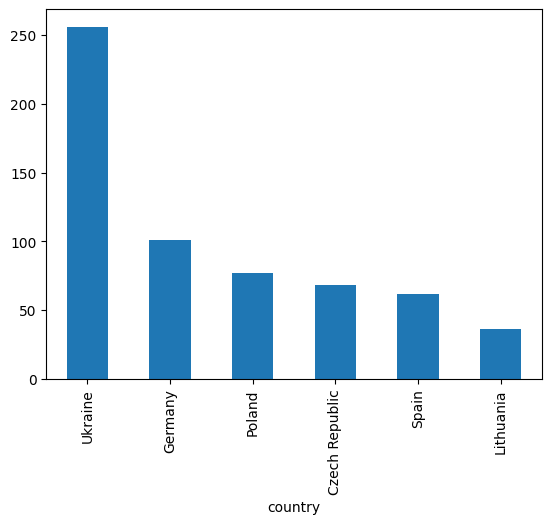

In [56]:
# Aufgabe 51:
subs["country"].value_counts().plot(kind="bar")
plt.show()


**Aufgabe 52.** Erstelle ein Kreisdiagramm (`pie`) der Verteilung der Abonnenten nach Tarifen.

> 💡 `value_counts().plot(kind="pie")`.


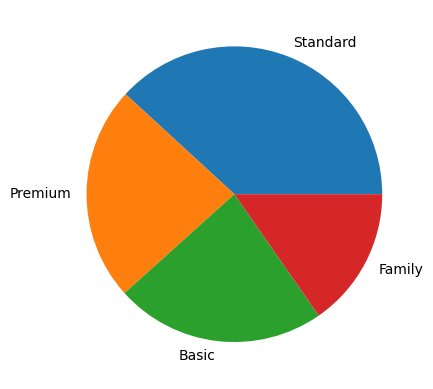

In [57]:
# Aufgabe 52:
subs['plan'].value_counts().plot(kind="pie", ylabel='')
plt.show()


**Aufgabe 53.** Erstelle ein Histogramm der Altersverteilung der Abonnenten.

> 💡 `subs["age"].plot(kind="hist")`.


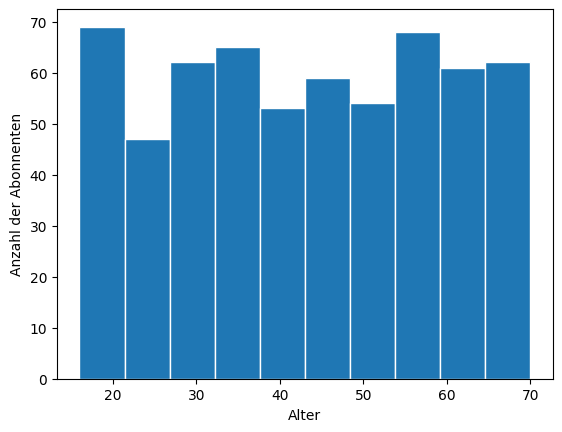

In [58]:
# Aufgabe 53:
subs["age"].plot(
    kind="hist",
    edgecolor="white",
    xlabel="Alter",
    ylabel="Anzahl der Abonnenten"
)
plt.show()



**Aufgabe 54.** Erstelle ein Histogramm der Sitzungsdauer mit 20 Intervallen (bins).

> 💡 Parameter `bins=20`.


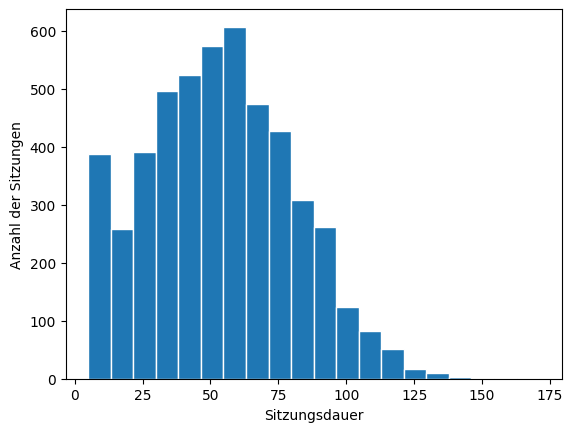

In [59]:
# Aufgabe 54:
sess['duration_min'].plot(
    kind='hist',
    bins=20,
    edgecolor='white'
)
plt.ylabel('Anzahl der Sitzungen')
plt.xlabel('Sitzungsdauer')
plt.show()


**Aufgabe 55.** Erstelle ein Liniendiagramm der Anzahl der Sitzungen nach Monaten. Gruppiere zuerst nach Monat, dann `.plot()`.

> 💡 `sess.groupby("month").size().plot()`.


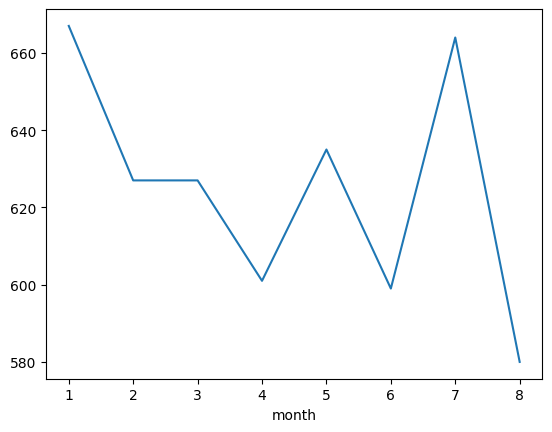

In [60]:
# Aufgabe 55:
sess.groupby("month").size().plot(
    kind='line'
)
#sess['month'].value_counts()
plt.show()


**Aufgabe 56.** Erstelle ein horizontales Balkendiagramm der Anzahl der Sitzungen nach Genres.

> 💡 `kind="barh"`.


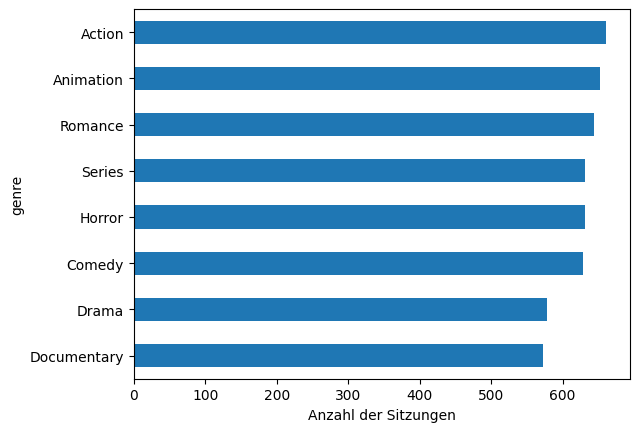

In [61]:
# Aufgabe 56:
sess.groupby('genre').size().sort_values().plot(
    kind='barh',
    xlabel='Anzahl der Sitzungen')
plt.show()


**Aufgabe 57.** Erstelle ein Balkendiagramm der durchschnittlichen Bewertung (`rating`) nach Genres.

> 💡 `groupby("genre")["rating"].mean().plot(kind="bar")`.


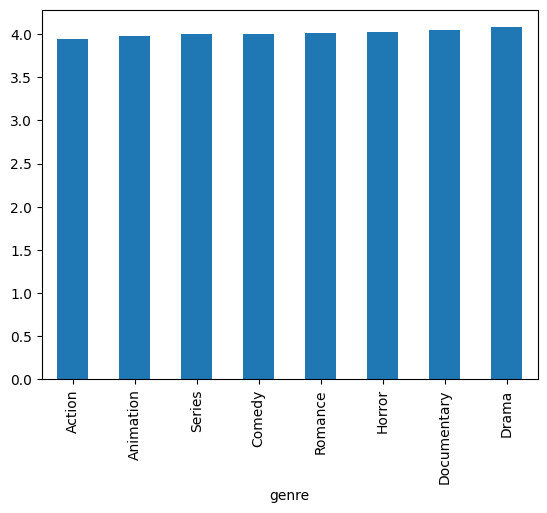

In [62]:
# Aufgabe 57:
sess.groupby('genre')['rating'].mean().sort_values().plot(
    kind='bar'
)
plt.show()


**Aufgabe 58.** Erstelle einen Scatter Plot (Streudiagramm): X-Achse — `duration_min`, Y-Achse — `rating` (aus der Tabelle `sess`).

> 💡 `sess.plot(kind="scatter", x="duration_min", y="rating")`.


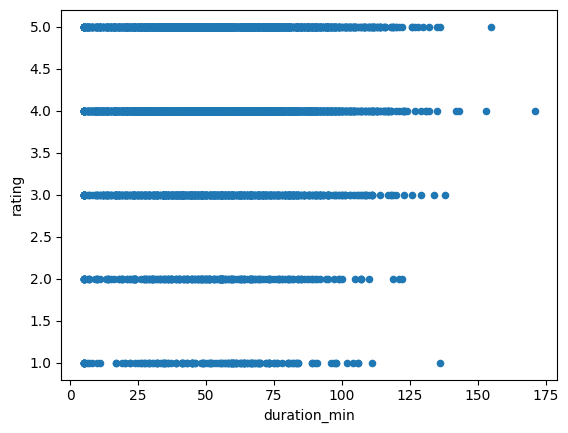

In [63]:
# Aufgabe 58:
sess.plot(kind="scatter",
          x="duration_min",
          y="rating"
          )
plt.show()


## Kapitel 2.2. matplotlib-Grundlagen (Aufgaben 59-66)

matplotlib gibt mehr Kontrolle. Grundsyntax:

```python
plt.figure(figsize=(8, 5))   # Diagrammgröße
plt.bar(Kategorien, Werte) # bar / line / scatter / hist
plt.title("Titel")
plt.xlabel("X-Name")
plt.ylabel("Y-Name")
plt.show()
```

Funktionen: `plt.bar()`, `plt.barh()`, `plt.plot()`, `plt.hist()`, `plt.scatter()`, `plt.pie()`.


**Aufgabe 59.** Erstelle ein Balkendiagramm mit `plt.bar()`. X-Achse — Länder, Y-Achse — Anzahl der Abonnenten.

> 💡 Hole zuerst die Daten: `counts = subs["country"].value_counts()`. Dann: `plt.bar(counts.index, counts.values)`.


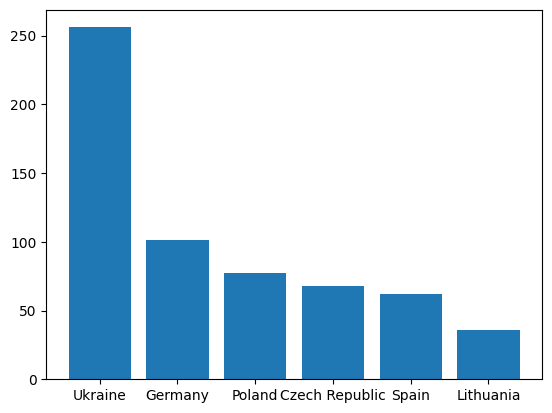

In [64]:
# Aufgabe 59:
counts = subs["country"].value_counts()
plt.bar(counts.index, counts.values)
plt.show()


**Aufgabe 60.** Erstelle ein Liniendiagramm mit `plt.plot()`: Entwicklung der Anzahl der Sitzungen nach Monaten.

> 💡 `monthly = sess.groupby("month").size()` + `plt.plot(monthly.index, monthly.values)`.


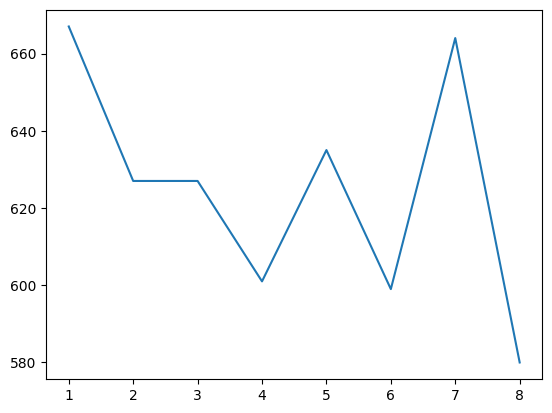

In [65]:
# Aufgabe 60:
monthly = sess.groupby("month").size()
plt.plot(monthly.index, monthly.values)
plt.show()


**Aufgabe 61.** Erstelle ein Histogramm des Alters der Abonnenten mit `plt.hist()` mit 15 Intervallen.

> 💡 `plt.hist(subs["age"], bins=15)`.


Text(0, 0.5, 'Anzahl')

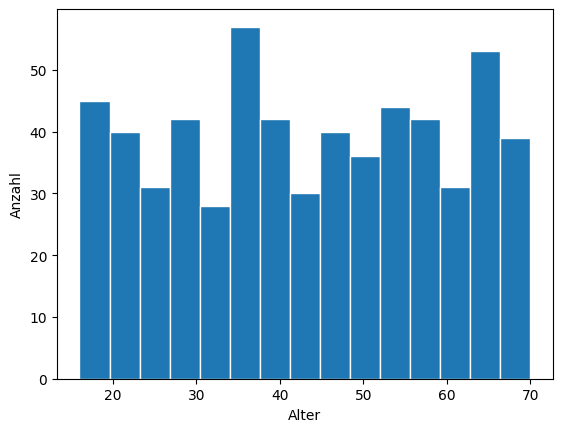

In [66]:
# Aufgabe 61:
plt.hist(subs['age'],
         bins=15,
         edgecolor='white'
         )
plt.xlabel("Alter")
plt.ylabel("Anzahl")


**Aufgabe 62.** Erstelle einen Streudiagramm mit `plt.scatter()`: Alter der Abonnenten auf X, monatliche Gebühr auf Y.

> 💡 `plt.scatter(subs["age"], subs["monthly_fee"])`.


Text(0, 0.5, 'Monatliche Gebühr')

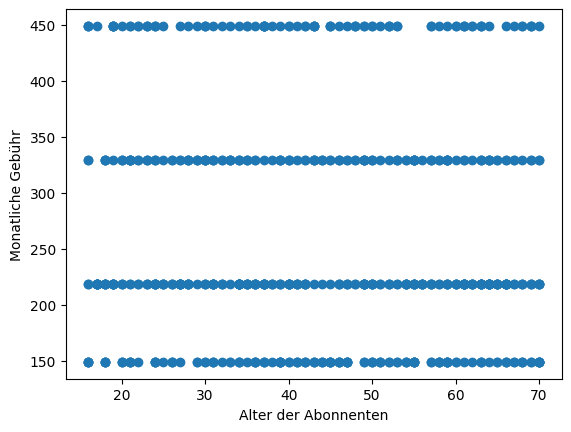

In [67]:
# Aufgabe 62:
plt.scatter(subs['age'], subs['monthly_fee'])
plt.xlabel("Alter der Abonnenten")
plt.ylabel("Monatliche Gebühr")


**Aufgabe 63.** Erstelle ein Kreisdiagramm mit `plt.pie()`: Verteilung der Sitzungen nach Geräten.

> 💡 `counts = sess["device"].value_counts()` + `plt.pie(counts.values, labels=counts.index)`.


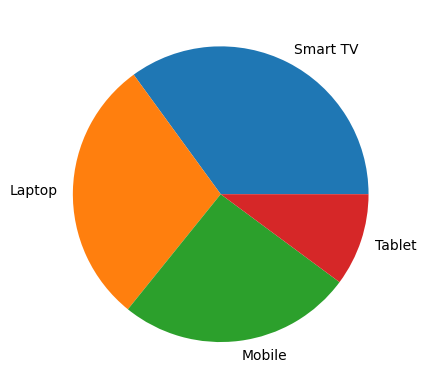

In [68]:
# Aufgabe 63:
counts = sess['device'].value_counts()
plt.pie(
    counts.values,
    labels=counts.index
)
plt.show()


**Aufgabe 64.** Erstelle ein Diagramm mit der Größe 10x6 Zoll mit `plt.figure(figsize=...)`. Du kannst ein beliebiges Diagramm erstellen — zum Beispiel die Anzahl der Sitzungen nach Genres.


<BarContainer object of 8 artists>

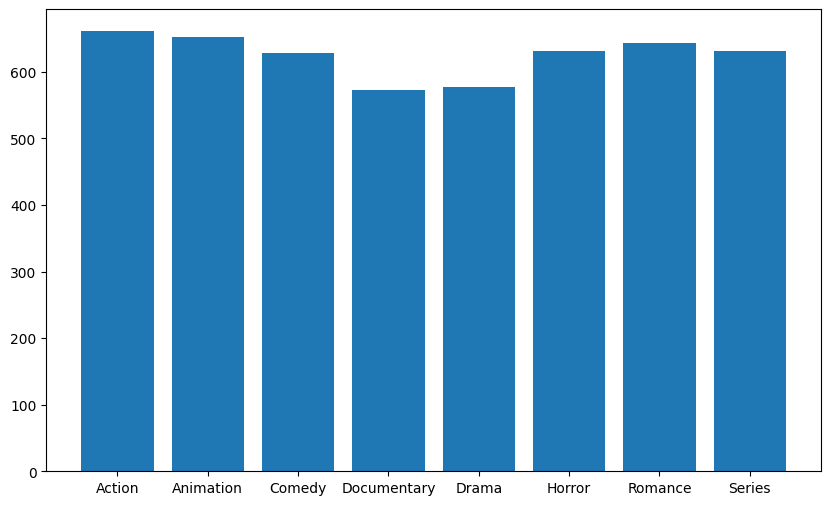

In [69]:
# Aufgabe 64:
plt.figure(figsize=(10,6))
genre_sess = sess.groupby('genre').size()
plt.bar(
    genre_sess.index,
    genre_sess.values
)


**Aufgabe 65.** Erstelle ein horizontales Balkendiagramm mit `plt.barh()`: Anzahl der Sitzungen nach Genres.


<BarContainer object of 8 artists>

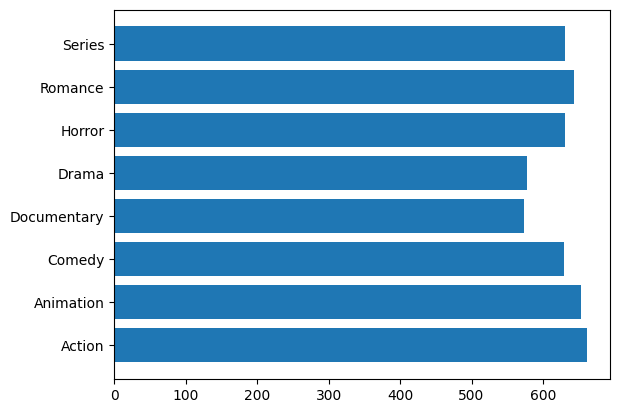

In [70]:
# Aufgabe 65:
plt.barh(
    genre_sess.index,
    genre_sess.values
)


**Aufgabe 66.** Erstelle zwei Histogramme in einer Abbildung (rufe `plt.hist` zweimal hintereinander vor `plt.show()` auf): Alter der aktiven und Alter der inaktiven Abonnenten. Verwende den Parameter `alpha=0.5` für Transparenz.

> 💡 `plt.hist(...aktive..., alpha=0.5)` dann `plt.hist(...inaktive..., alpha=0.5)` dann `plt.show()`.


In [71]:
subs[subs["is_active"]=="Yes"]['age']
subs.loc[subs["is_active"]=="Yes",'age']


,age
0,19
1,40
2,60
3,36
4,34
...,...
594,70
595,53
596,30
597,38


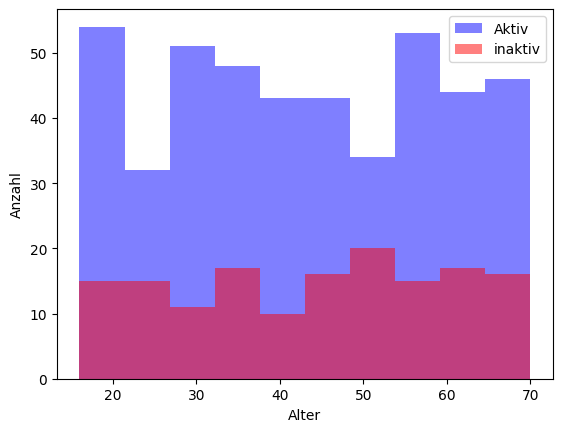

In [72]:
# Aufgabe 66:

plt.hist(subs[subs["is_active"]=="Yes"]['age'], alpha=0.5, color='blue', label='Aktiv')
plt.hist(subs[subs["is_active"]=="No"]['age'], alpha=0.5, color='red', label='inaktiv')
plt.xlabel('Alter')
plt.ylabel('Anzahl')
plt.legend()
plt.show()



## Kapitel 2.3. Diagramme anpassen (Aufgaben 67-74)

Jetzt fügen wir Schönheit und Aussagekraft hinzu:
- `plt.title("...")` — Titel
- `plt.xlabel("...")`, `plt.ylabel("...")` — Achsenbeschriftungen
- `color="..."` — Farbe (`"red"`, `"#02C39A"`, `"teal"` usw.)
- `plt.xticks(rotation=45)` — X-Beschriftungen drehen
- `plt.grid(True)` — Gitter hinzufügen
- `plt.figure(figsize=(w, h))` — Größe


**Aufgabe 67.** Erstelle ein Balkendiagramm der Anzahl der Abonnenten nach Ländern. Füge den Titel "Anzahl der Abonnenten nach Ländern", die X-Achsenbeschriftung "Land" und die Y-Achsenbeschriftung "Anzahl" hinzu.


In [73]:
# Vorbereitung:
subs_by_country = subs["country"].value_counts()


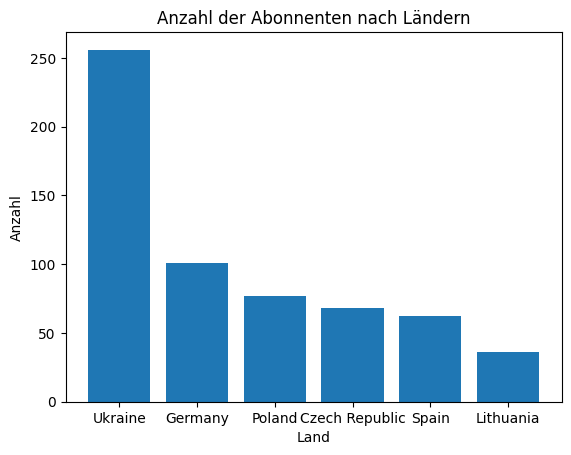

In [74]:
# Aufgabe 67:
plt.bar(subs_by_country.index, subs_by_country.values)
plt.title("Anzahl der Abonnenten nach Ländern")
plt.xlabel("Land")
plt.ylabel("Anzahl")
plt.show()


**Aufgabe 68.** Erstelle ein Diagramm der durchschnittlichen Sitzungsdauer nach Genres. Mache alle Balken in der FARBE `teal`.

> 💡 Parameter `color="teal"` innerhalb von `plt.bar()` oder `.plot(kind="bar")`.


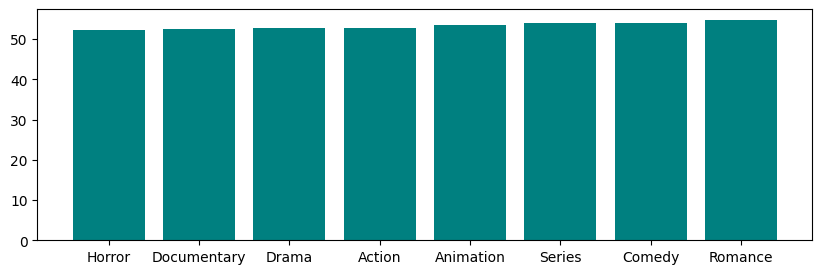

In [75]:
# Aufgabe 68:
dur_genre = sess.groupby("genre")["duration_min"].mean().round(2).sort_values()
plt.figure(figsize=(10,3))
plt.bar(
    dur_genre.index,
    dur_genre.values,
    color='teal'
)
plt.show()


**Aufgabe 69.** Erstelle ein Histogramm des Alters mit 20 Intervallen. Farbe — `"#02C39A"` (türkis), füge einen Titel hinzu.


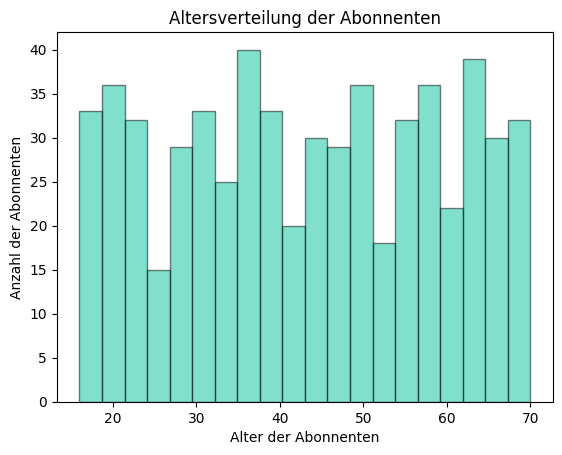

In [76]:
# Aufgabe 69:
plt.hist(subs['age'],bins=20,alpha=0.5,edgecolor='black',color='#02C39A')
plt.xlabel("Alter der Abonnenten")
plt.ylabel("Anzahl der Abonnenten")
plt.title("Altersverteilung der Abonnenten")
plt.show()


**Aufgabe 70.** Erstelle ein Diagramm der Anzahl der Sitzungen nach Monaten. Drehe die Beschriftungen auf der X-Achse um 45 Grad.

> 💡 `plt.xticks(rotation=45)`.


In [77]:
# Aufgabe 70:
monthly = sess.groupby(sess['date'].dt.month_name())['session_id'].count()
month_order = ['January', 'February', 'March', 'April',
               'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']

monthly.index = pd.Categorical(monthly.index, categories=month_order, ordered=True)
monthly = monthly.sort_index()


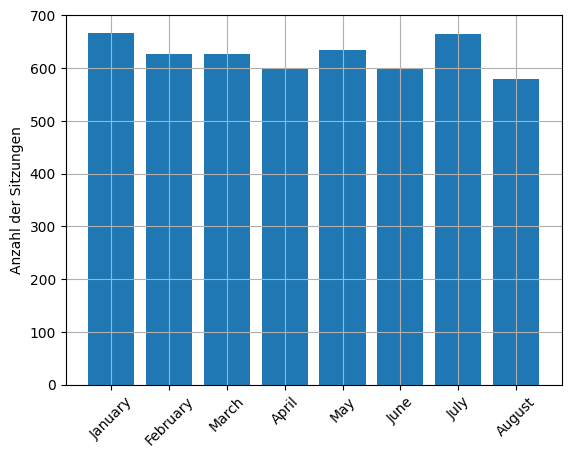

In [78]:

plt.bar(monthly.index,
        monthly.values)
plt.grid()
plt.xticks(rotation=45)
plt.ylabel("Anzahl der Sitzungen")
plt.show()


**Aufgabe 71.** Erstelle ein Balkendiagramm des durchschnittlichen `monthly_fee` nach Tarifen. Abbildungsgröße 8x5. Füge ein Gitter hinzu.

> 💡 `plt.grid(True)`. Ein Gitter für Balkendiagramme sieht nur auf der Y-Achse besser aus: `plt.grid(axis="y")`.


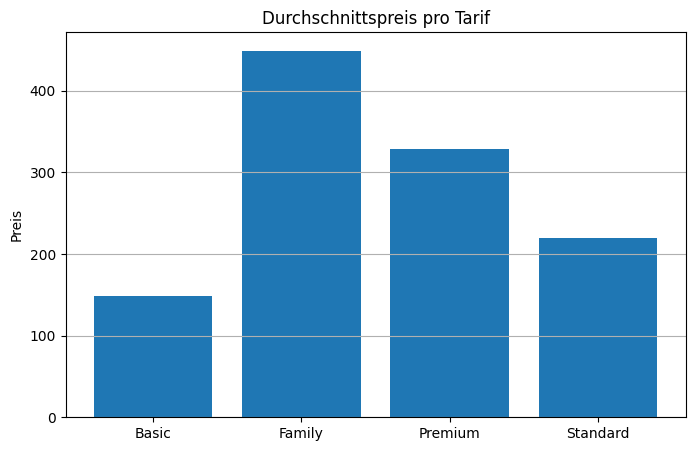

In [79]:
# Aufgabe 71:
plt.figure(figsize=(8,5))
avg_plan = subs.groupby("plan")['monthly_fee'].mean()
plt.bar(avg_plan.index,
        avg_plan.values)
plt.grid(axis="y")
plt.title("Durchschnittspreis pro Tarif")
plt.ylabel("Preis")
plt.show()


**Aufgabe 72.** Erstelle ein Liniendiagramm der Anzahl der Sitzungen nach Monaten. Linienart: gestrichelt, Farbe rot, Marker in Form von Punkten.

> 💡 In `plt.plot()` Parameter: `linestyle="--"`, `color="red"`, `marker="o"`. Oder kurz: `"r--o"`.


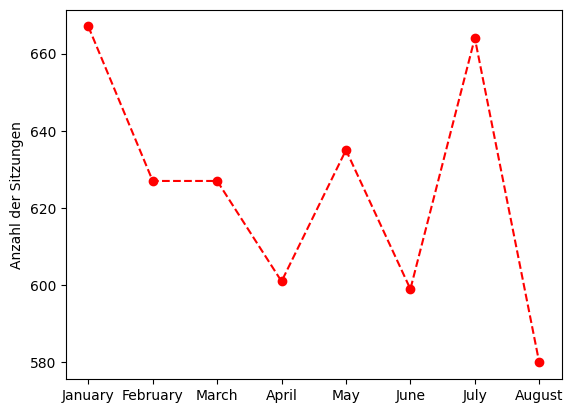

In [80]:
# Aufgabe 72:
#plt.plot(monthly, linestyle="--", color="red", marker="o")
plt.plot(monthly,"r--o")
plt.ylabel("Anzahl der Sitzungen")
plt.show()


**Aufgabe 73.** Erstelle einen Scatter Plot: Alter (X) vs monatliche Gebühr (Y). Mache die Punktfarbe halbtransparent (`alpha=0.3`).


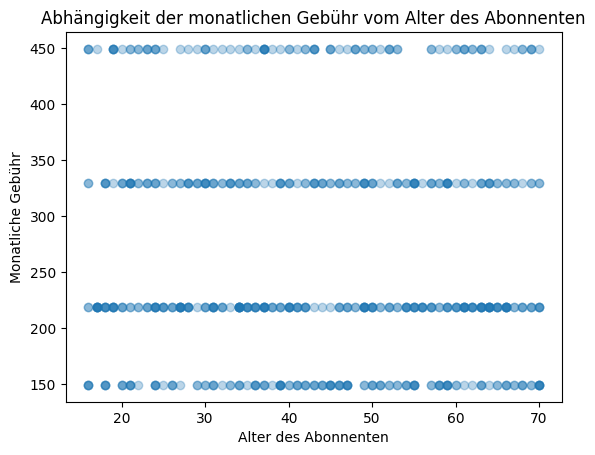

In [81]:
# Aufgabe 73:
plt.scatter(subs['age'],subs['monthly_fee'],alpha=0.3)
plt.xlabel("Alter des Abonnenten")
plt.ylabel("Monatliche Gebühr")
plt.title("Abhängigkeit der monatlichen Gebühr vom Alter des Abonnenten")
plt.show()


**Aufgabe 74.** Erstelle ein Kreisdiagramm der Verteilung der Abonnenten nach Tarifen. Zeige die Prozentsätze in jedem Segment an.

> 💡 Parameter `autopct="%1.1f%%"` in `plt.pie()`.


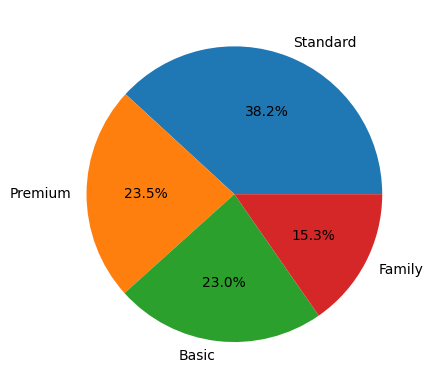

In [82]:
# Aufgabe 74:
subs['plan'].value_counts()
plt.pie(subs['plan'].value_counts(),
        autopct="%1.1f%%",
        labels=subs['plan'].value_counts().index)
plt.show()


## Kapitel 2.4. Legenden, mehrere Serien, Subplots (Aufgaben 75-80)

Mehrere Serien in einem Diagramm:
- Jede Serie hat den Parameter `label="..."`
- Wir rufen `plt.legend()` auf — zeigt die Legende an

Mehrere Diagramme nebeneinander (Subplots):
```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(...)
axes[0].set_title("Erstes")
axes[1].plot(...)
axes[1].set_title("Zweites")
plt.show()
```


**Aufgabe 75.** Erstelle in einem Diagramm zwei Linien: Anzahl der Sitzungen nach Monaten für Smart TV und für Mobile. Füge eine Legende mit Beschriftungen hinzu.

> 💡 Rufe `plt.plot(...)` zweimal mit unterschiedlichen Daten auf, jedes mit dem Parameter `label="..."`. Dann `plt.legend()`.


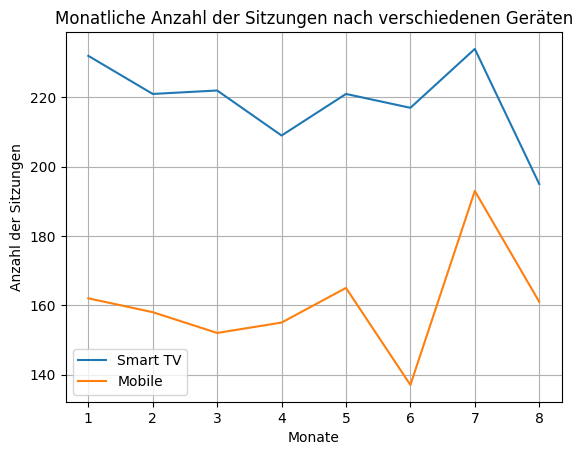

In [83]:
# Aufgabe 75:
plt.plot(sess[sess['device']=='Smart TV'].groupby('month')['session_id'].count(), label='Smart TV')
plt.plot(sess[sess['device']=='Mobile'].groupby('month')['session_id'].count(), label='Mobile')
plt.legend()
plt.title('Monatliche Anzahl der Sitzungen nach verschiedenen Geräten')
plt.xlabel("Monate")
plt.ylabel("Anzahl der Sitzungen")
plt.grid(True)


**Aufgabe 76.** Erstelle in einem Diagramm zwei Altershistogramme: separat für Männer und Frauen (mit Transparenz `alpha=0.5` und unterschiedlichen Farben). Füge eine Legende hinzu.


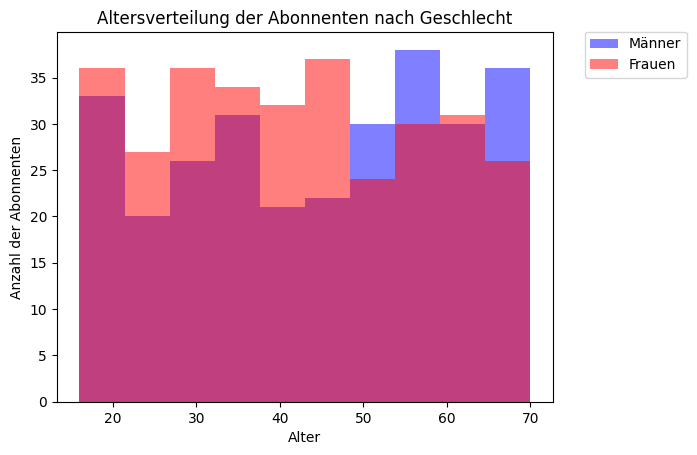

In [84]:
# Aufgabe 76:
plt.hist(subs[subs["gender"]=="m"]['age'], alpha=0.5, color='blue', label='Männer')
plt.hist(subs[subs["gender"]=="f"]['age'], alpha=0.5, color='red', label='Frauen')
plt.title("Altersverteilung der Abonnenten nach Geschlecht")
plt.xlabel("Alter")
plt.ylabel("Anzahl der Abonnenten")
plt.legend(bbox_to_anchor=(1.05, 1.02), loc='upper left')
plt.show()


**Aufgabe 77.** Erstelle zwei Balkendiagramme nebeneinander mit `subplots(1, 2)`:
- links: Anzahl der Abonnenten nach Ländern
- rechts: Anzahl der Abonnenten nach Tarifen

Füge jedem einen Titel hinzu.


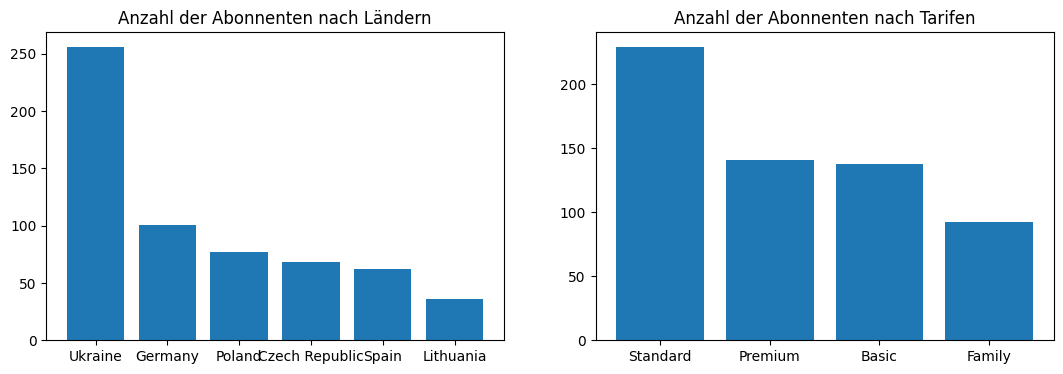

In [85]:
# Aufgabe 77:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(subs['country'].value_counts().index, subs['country'].value_counts().values)
axes[0].set_title("Anzahl der Abonnenten nach Ländern")
axes[1].bar(subs['plan'].value_counts().index, subs['plan'].value_counts().values)
axes[1].set_title("Anzahl der Abonnenten nach Tarifen")
plt.show()


**Aufgabe 78.** Erstelle ein 2x2-Raster von Diagrammen (`subplots(2, 2)`):
- (0,0): Histogramm des Alters
- (0,1): Anzahl der Sitzungen nach Genres (bar)
- (1,0): Verteilung der Geräte (pie)
- (1,1): durchschnittliche Dauer nach Genres (barh)

Füge jedem einen Titel hinzu. Abbildungsgröße — 12x10.

> 💡 `fig, axes = plt.subplots(2, 2, figsize=(12, 10))`. Zugriff: `axes[0, 0]`, `axes[0, 1]`, `axes[1, 0]`, `axes[1, 1]`.


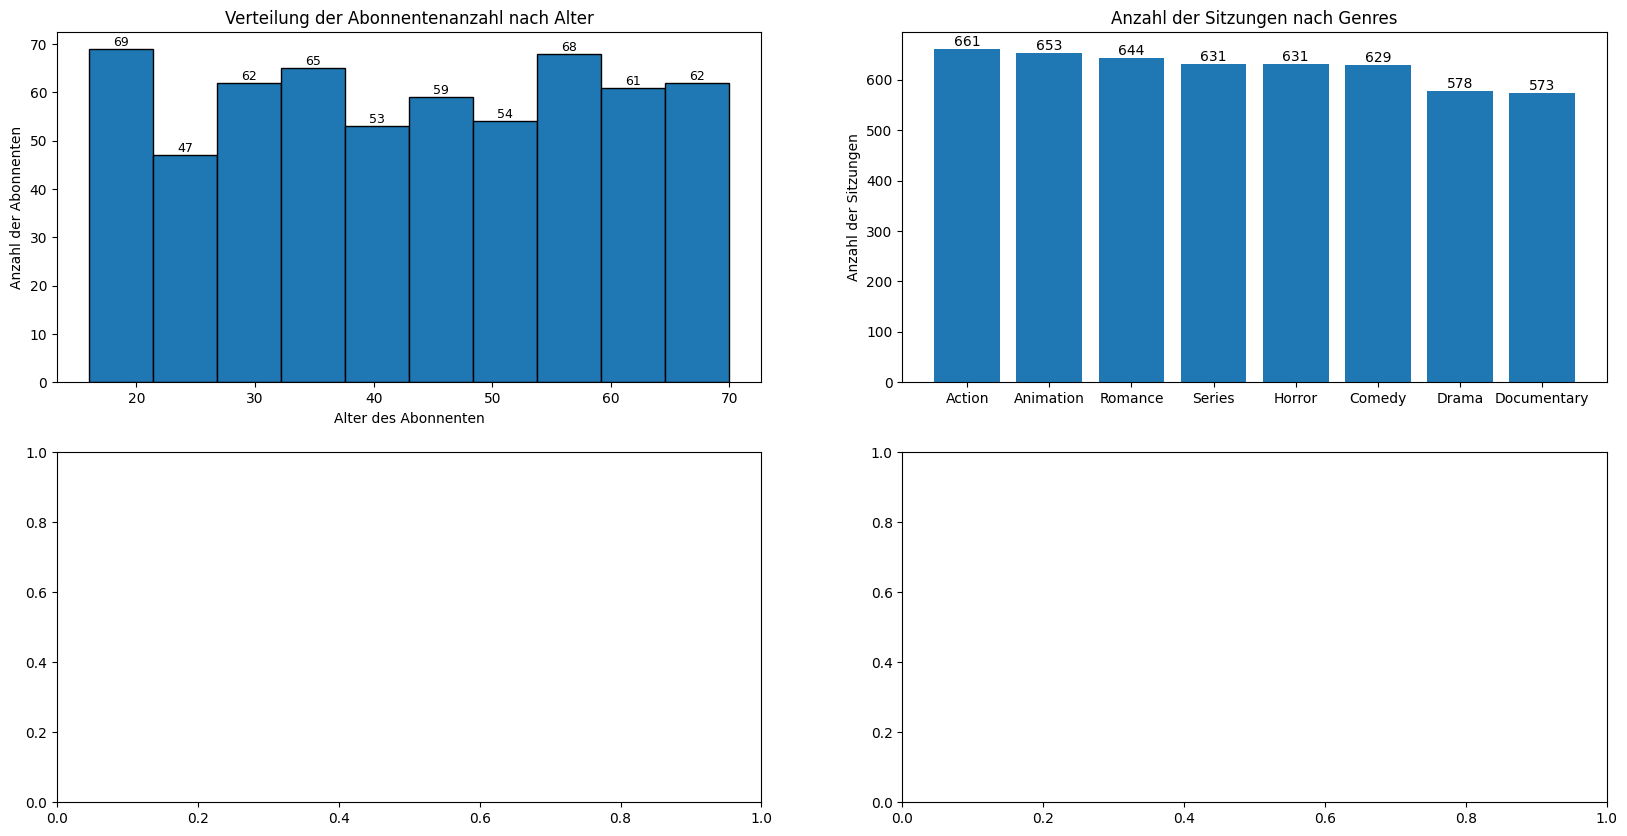

<BarContainer object of 8 artists>

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
n, bins, patches = axes[0,0].hist(subs['age'], edgecolor='black')

for patch in patches:
    height = patch.get_height()
    if height > 0:  # leere Balken nicht beschriften
        axes[0,0].text(
            patch.get_x() + patch.get_width() / 2,
            height,
            str(int(height)),
            ha='center', va='bottom',
            fontsize=9
        )

axes[0,0].set_xlabel("Alter des Abonnenten")
axes[0,0].set_ylabel("Anzahl der Abonnenten")
axes[0,0].set_title("Verteilung der Abonnentenanzahl nach Alter")
#--------------------
genre_cnt = sess['genre'].value_counts()
bars = axes[0,1].bar(genre_cnt.index, genre_cnt.values)
axes[0,1].bar_label(bars)
axes[0,1].set_ylabel("Anzahl der Sitzungen")
axes[0,1].set_title("Anzahl der Sitzungen nach Genres")
plt.show()
bars


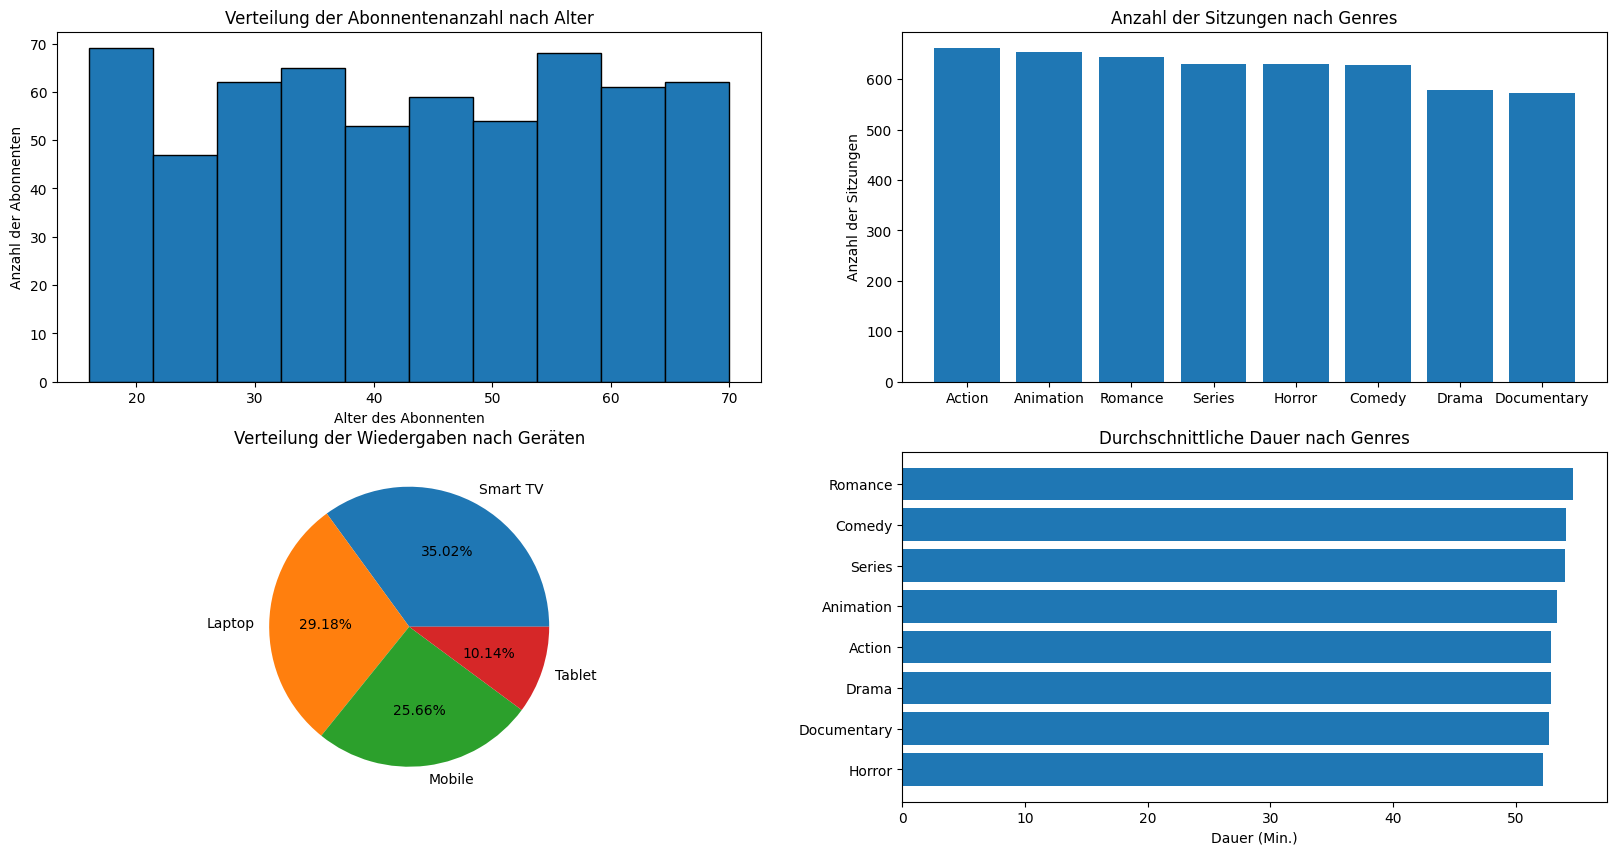

In [87]:
# Aufgabe 78:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes[0,0].hist(subs['age'],edgecolor='black')
axes[0,0].set_xlabel("Alter des Abonnenten")
axes[0,0].set_ylabel("Anzahl der Abonnenten")
axes[0,0].set_title("Verteilung der Abonnentenanzahl nach Alter")

genre_cnt = sess['genre'].value_counts()
axes[0,1].bar(genre_cnt.index, genre_cnt.values)
axes[0,1].set_ylabel("Anzahl der Sitzungen")
axes[0,1].set_title("Anzahl der Sitzungen nach Genres")

axes[1,0].pie(sess['device'].value_counts(),labels=sess['device'].value_counts().index,autopct='%1.2f%%')
axes[1,0].set_title("Verteilung der Wiedergaben nach Geräten")

avg_genre = sess.groupby('genre')['duration_min'].mean().round(1).sort_values()
axes[1,1].barh(avg_genre.index, avg_genre.values)
axes[1,1].set_title('Durchschnittliche Dauer nach Genres')
axes[1,1].set_xlabel('Dauer (Min.)')
plt.show()



**Aufgabe 79.** Erstelle ein Diagramm der durchschnittlichen Bewertung nach Genres. Färbe die Balken in UNTERSCHIEDLICHEN Farben (übergib eine Farbliste im Parameter `color`).

> 💡 `color=["red","blue","green","orange","purple","teal","pink","gray"]` — so viele Farben wie Genres.


<BarContainer object of 8 artists>

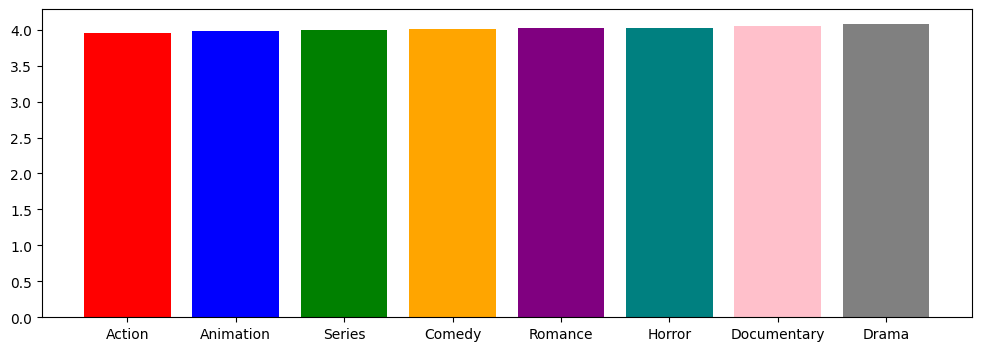

In [88]:
# Aufgabe 79:
plt.figure(figsize=(12,4))
avg_rating_genre = sess.groupby('genre')['rating'].mean().round(2).sort_values()
plt.bar(avg_rating_genre.index, avg_rating_genre.values, color=["red","blue","green","orange","purple","teal","pink","gray"])


**Aufgabe 80.** Erstelle ein finales Dashboard: 2x1-Raster (ein Diagramm über dem anderen), Größe 10x10.
- oben: Liniendiagramm der Anzahl der Sitzungen nach Monaten, mit dem Titel "Entwicklung der Wiedergaben 2024"
- unten: horizontales Balkendiagramm der Top-10-Genres nach Anzahl der Sitzungen, mit dem Titel "Top-Genres"

Zum Schluss — `plt.tight_layout()` (behebt Überlappungen).

> 💡 `fig, axes = plt.subplots(2, 1, figsize=(10, 10))` + am Ende `plt.tight_layout()`.


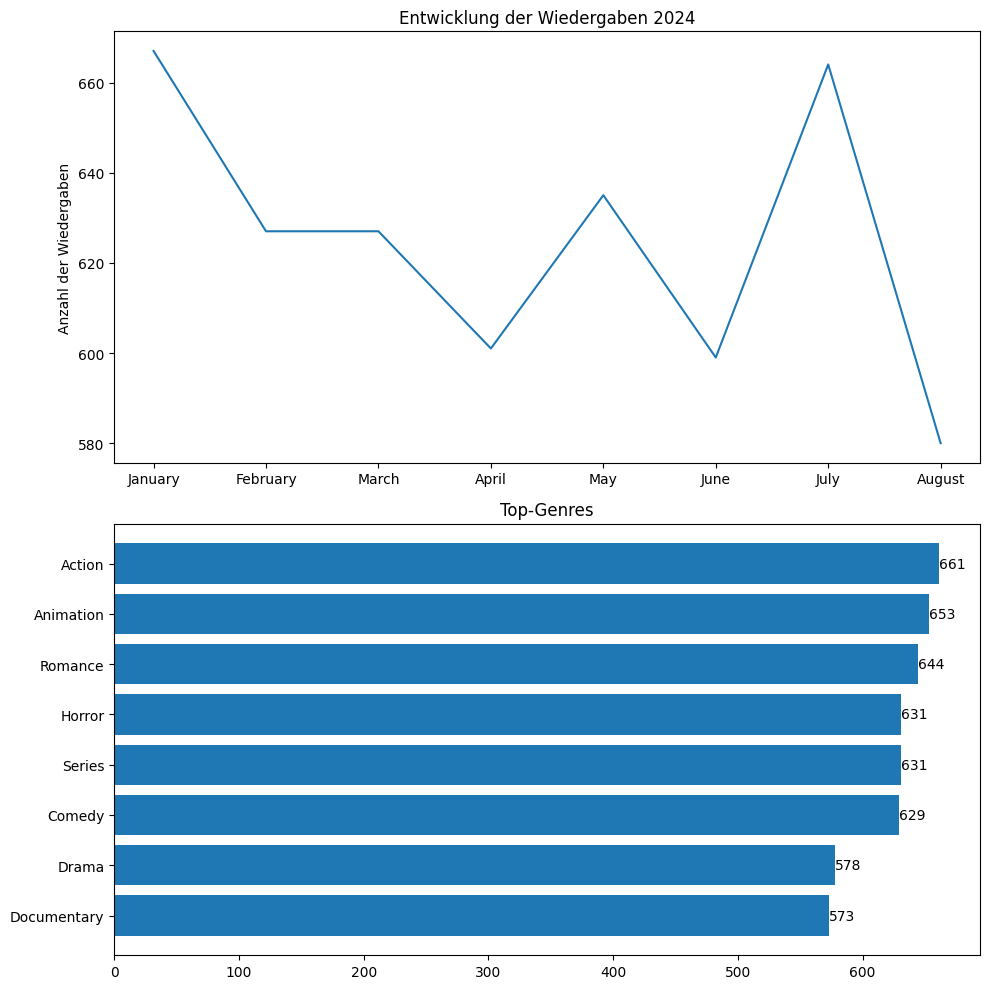

In [89]:
# Aufgabe 80:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
axes[0].plot(monthly.index, monthly.values)
axes[0].set_title("Entwicklung der Wiedergaben 2024")
axes[0].set_ylabel('Anzahl der Wiedergaben')

#insgesamt gibt es 8 Genres im Datensatz
top8_genre = sess['genre'].value_counts().sort_values()
bars = axes[1].barh(top8_genre.index, top8_genre.values)
axes[1].bar_label(bars)
axes[1].set_title('Top-Genres')

plt.tight_layout()
plt.show()


---

# 🎉 Fertig!

Wenn du alle 80 Aufgaben gelöst hast — herzlichen Glückwunsch! Du hast trainiert:

**Pandas (50 Aufgaben):**
- ✅ `loc` und `iloc` — mächtige Auswahl nach Position und Bedingung
- ✅ Komplexeres `groupby` mit `.agg()`, `.transform()`, Gruppierung nach mehreren Spalten
- ✅ `pivot_table` — Pivot-Tabellen im Excel-Stil
- ✅ Arbeiten mit Datumsangaben (`.dt.month`, `.dt.day_name`, Datumsdifferenz)
- ✅ Zusammenführen von Tabellen mit `merge`

**Matplotlib (30 Aufgaben):**
- ✅ Schnelle Diagramme mit pandas `.plot()`
- ✅ Grundlegende matplotlib-Funktionen: `bar`, `plot`, `hist`, `scatter`, `pie`
- ✅ Anpassungen: Titel, Achsen, Farben, Gitter
- ✅ Legenden und mehrere Serien in einem Diagramm
- ✅ Subplots — mehrere Diagramme nebeneinander

### Tipp
Der beste Weg, sich das zu merken: kehre nach einer Woche zurück und versuche die schwierigsten Aufgaben noch einmal, ohne nachzuschauen. **Weiter so! 🐼📊**


